# Как запускать connectpt — инструкция на Mandl

Справочник по запуску частей проекта в разных режимах. Все примеры — на маленьком
бенчмарке **Mandl** (15 узлов), каждая ячейка выполняется быстро (секунды — пара
минут). Экспериментальный ноутбук статьи — `paper_combined.ipynb`; здесь только
демонстрация API.

**Главные правила проекта**

- **Config-first**: один эксперимент = один YAML в
  `connectpt/routes_generator/cfg/experiments/`. Новый результат = новый/правленый
  YAML, а не правка кода и не циклы подмены значений из Python.
- **Smoke-режим**: у каждого эксперимента есть `*_smoke.yaml` — тот же конфиг с
  бюджетом 1–2 итерации; smoke-профиль ноутбука пишет все выходы с префиксом
  `TEMP_` в отдельную папку.
- **Objective один**: `cfg/objective/rtt_wmc_no_demand.yaml`
  (`alpha*RTT + (1-alpha)*WMC + штраф за adjustment`) через `CostFactory` —
  никакие веса не задаются в ячейках.
- Полные бюджеты статьи (сотни BCO-итераций, обучение PPO) в ноутбуках не гоняем —
  их запускает пользователь отдельно.

## Режимы запуска — сводка

| Режим | Как включить | Что делает |
|---|---|---|
| smoke | `load_experiment("<имя>_smoke")` / `load_suite("suite_smoke")` | тот же YAML с бюджетом 1–2 итерации, выходы `TEMP_` |
| full | `load_experiment("<имя>")` / `load_suite("suite")` | бюджет статьи (гоняет пользователь) |
| dry-run | `.run(dry_run=True)` | собрать модели/план/конфиг без поиска и обучения |
| overrides | `load_experiment(name, overrides=[...])` | точечные правки поверх YAML — для отладки; настоящий эксперимент = отдельный YAML |
| прогресс | override `+run.silent=false` | живые tqdm-бары BCO-поиска |
| CPU | override `run.cpu=true` | принудительно CPU (по умолчанию GPU, если есть) |

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from connectpt.routes_generator.core import build_experiment, load_experiment, load_suite
from connectpt.routes_generator.core.batches import ExperimentBatch, ExperimentRunFactory
from connectpt.routes_generator.core.paths import ROOT_DIR

## 1. Данные: инстанс Mandl

Любой источник данных (benchmark / MACSA / EKB) загружается в один и тот же
`Instance`: тензоры графа (`node_locs`, `street_adj`, `demand`), начальная сеть
`init_routes` и границы маршрутов `spec`. Новый датасет = новый `DataSource` в
`data/sources.py` + YAML с `data.source: <имя>` — весь остальной конвейер общий.

Здесь берём запинённую Initial-сеть Таблицы 1 (детерминированно). Без `init_dump`
сеть строится с нуля: learned construction + realistic tier.

In [2]:
from connectpt.routes_generator.data.sources import BenchmarkDataSource

table1_dir = ROOT_DIR / "artifacts/paper_final/table1_e1u_unified_alpha05_target02"
inst = BenchmarkDataSource(
    city="Mandl", init_dump=str(table1_dir / "final_main_unified_Mandl_routes.pt")).load()
print(inst.label, "| spec:", inst.spec)
print("тензоры:", {k: tuple(v.shape) for k, v in inst.tensors.items()})

Mandl | spec: {'city': 'Mandl', 'n_routes': 6, 'min_route_len': 2, 'max_route_len': 8}
тензоры: {'node_locs': (15, 2), 'street_adj': (15, 15), 'demand': (15, 15)}


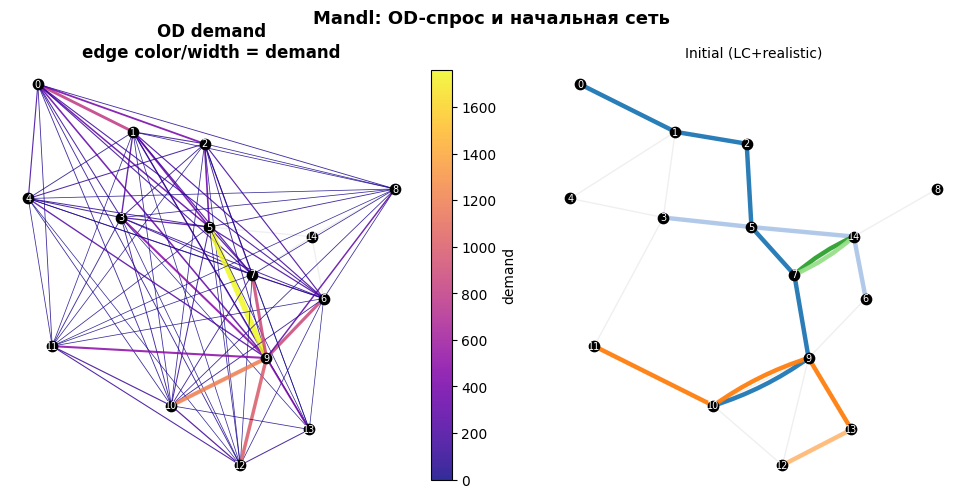

In [3]:
from connectpt.routes_generator.reports import plot_routes_grid

plot_routes_grid({"Initial (LC+realistic)": inst.init_routes},
                 inst.coords, inst.street_adj, demand=inst.tensors["demand"],
                 ncols=2, title="Mandl: OD-спрос и начальная сеть")
plt.show()

## 2. Скоринг фиксированной сети — атом `score_fixed_routes`

Оценить ГОТОВЫЙ набор маршрутов под unified objective (без поиска): cost собирается
`CostFactory` из objective-YAML, `alpha` задаёт компромисс RTT/WMC. Adjustment-штраф
включается только если передать `adj_target=` и `seed_routes=` (так скорятся
Table-B-сети MACSA); без них — как Initial-строки статьи.

In [4]:
from connectpt.routes_generator.evaluation import full_metric_row, score_fixed_routes

metrics, scored = score_fixed_routes(inst.init_routes, inst.tensors, inst.spec, alpha=0.5)
row = full_metric_row(metrics, scored, inst.init_routes)
pd.DataFrame([row]).round(3)

,ATT,RTT,WMC,WMC_mean,WMC_median,adj_vs_seed,rtt_cost,wmc_cost,cost,d0,d1,d2,d_un,redun%
0,12.453,132.0,15.659,22.686,15.659,0.0,0.667,0.475,2.35,61.272,26.846,1.606,10.276,13.333


In [5]:
# сверка с таргетом статьи (эта же строка проверяется в tests/test_paper_parity_mandl.py)
targets = pd.read_csv(table1_dir / "final_main_unified_Mandl.csv")
targets.loc[targets.method == "Initial (LC+realistic)",
            ["method", "RTT", "WMC", "cost", "adj_vs_seed"]].round(3)

,method,RTT,WMC,cost,adj_vs_seed
0,Initial (LC+realistic),132.0,15.659,2.35,0.0


## 3. Декларативный эксперимент: BCO-поиск по YAML

Эксперимент = YAML → `ExperimentRunFactory.from_cfg(cfg).run()`. Если в конфиге
есть блок `sweep:` — это свип `alpha x adj_target`, на выходе таблица + маршруты
каждой точки (и Парето-фронт в отчёте).

### 3.1 dry-run: собрать модели и план пчёл, ничего не запускать

In [6]:
cfg = load_experiment("e1/our_nbco")            # city defaults to Mandl
art = ExperimentRunFactory.from_cfg(cfg).run(dry_run=True)
art.plan

{'counts': {'neural_rebuild': 5,
  'type2': 0,
  'type3': 0,
  'type4': 0,
  'neural_edit_trimext': 5,
  'type6': 0,
  'type7': 0},
 'needs_construction': True,
 'needs_edit': True,
 'n_bees': 10}

### 3.2 smoke-свип (бюджет из `our_nbco_smoke.yaml`: 2 итерации)

`+run.silent=false` включает tqdm-прогресс поиска.

In [7]:
cfg = build_experiment("e1/our_nbco", smoke=True)
art = ExperimentRunFactory.from_cfg(cfg).run()
art.table.round(3)

,RTT,WMC,ATT,adj_vs_seed,redun%,cost,method,alpha,adj_target,n_iterations
0,274.0,10.286,10.976,0.301,26.923,0.312,Our NBCO (GNN rebuild + trim/extend),0.0,0.3,2
1,146.0,14.675,13.480,0.333,6.667,0.591,Our NBCO (GNN rebuild + trim/extend),0.5,0.3,2
2,146.0,14.675,13.480,0.333,6.667,0.737,Our NBCO (GNN rebuild + trim/extend),1.0,0.3,2


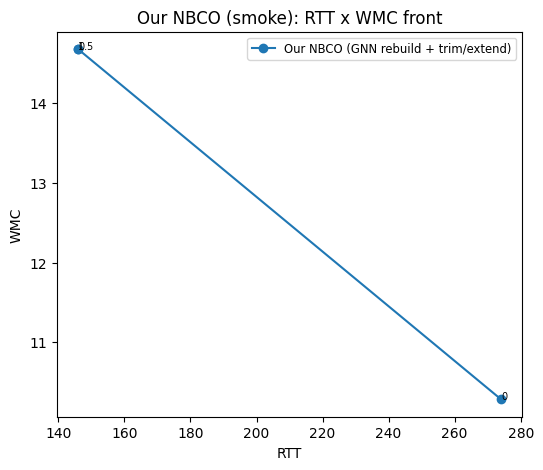

In [8]:
from connectpt.routes_generator import render_report

report = render_report(art, title="Our NBCO (smoke)")
report.figures["pareto"]
plt.show()

### 3.3 overrides: точечные правки поверх YAML

Для отладки/инструкций; воспроизводимый эксперимент оформляется отдельным YAML.

In [9]:
cfg = build_experiment(
    "e1/our_nbco",
    alpha=[0.5],        # None -> default from YAML
    n_iterations=3,
    cpu=True,
)
art3 = ExperimentRunFactory.from_cfg(cfg).run()
art3.table.round(3)

,RTT,WMC,ATT,adj_vs_seed,redun%,cost,method,alpha,adj_target,n_iterations
0,146.0,14.675,13.48,0.333,6.667,0.591,Our NBCO (GNN rebuild + trim/extend),0.5,0.3,3


## 4. Один seeded-запуск: улучшить ГОТОВУЮ сеть

Контракт статьи — «улучшить существующую сеть»: те же модели/пчёлы из YAML, но
`run(init_routes=..., tensors=..., eval_dims=...)` вместо свипа. Бюджет берётся из
`search.n_iterations`.

In [10]:
from connectpt.routes_generator.search import BeeColonySearchRun

cfg = load_experiment("e1/our_nbco", overrides=["search.n_iterations=5"])
art4 = BeeColonySearchRun(cfg).run(
    init_routes=inst.init_routes, tensors=inst.tensors, eval_dims=inst.spec)
pd.DataFrame([full_metric_row(art4.result["metrics"], art4.result["routes"],
                              inst.init_routes)]).round(3)

,ATT,RTT,WMC,WMC_mean,WMC_median,adj_vs_seed,rtt_cost,wmc_cost,cost,d0,d1,d2,d_un,redun%
0,13.017,156.0,12.503,NaN,NaN,0.204,NaN,NaN,0.583,70.649,23.892,5.202,0.257,11.765


## 5. From-scratch: построить сеть с нуля (construction-only)

Конфиг без блока `sweep:` и без `data.source:` → путь `run_suite`: сеть строится с
нуля construction-пчёлами на benchmark-инстансе (аналог learned-construction
прогонов старого evaluation.ipynb).

D:\PythonProjects\connectpt\connectpt\routes_generator\initialization.py:200: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:353.)
  are_on_route[[seed_pair]] = True


mean cost: 2.782


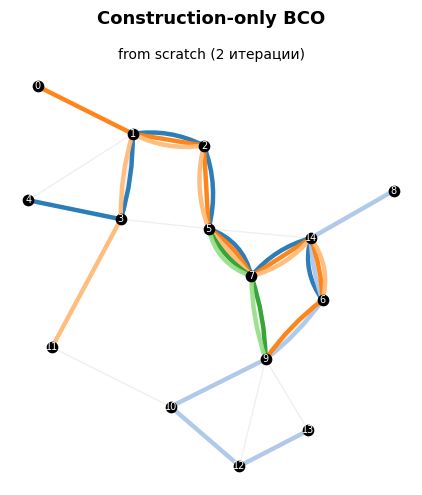

In [11]:
cfg = load_experiment("construction_only/mandl", overrides=["search.n_iterations=2"])
art5 = ExperimentRunFactory.from_cfg(cfg).run()
print("mean cost:", round(art5.result["mean_cost"], 3))
plot_routes_grid({"from scratch (2 итерации)": art5.result["routes"]},
                 inst.coords, inst.street_adj, title="Construction-only BCO")
plt.show()

## 6. Батчи и paper-обёртки (как в `paper_combined`)

Suite-профиль (`suite.yaml` / `suite_smoke.yaml`) — переключатели экспериментов,
префикс выходов и paper-папка (`artifacts/paper_results_v2`). Обёртки
`run_experiment` / `run_batch` сами выбирают `_smoke`-вариант из suite, сохраняют
таблицу + дамп маршрутов и рендерят отчёт — в ячейке ни путей, ни префиксов.

Низкоуровневый эквивалент батча: `ExperimentBatch(load_suite("e1/mandl/batch_smoke")).run()`.

In [12]:
from connectpt.routes_generator.paper_experiments.paper_runs import run_batch, run_experiment

suite = load_suite("suite_smoke")
e1 = run_batch("e1/batch", suite, city="Mandl")   # neural BCO vs Our NBCO
e1.table

[paper] table (6 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results_v2\TEMP_e1_mandl_smoke.csv


,run,RTT,WMC,ATT,adj_vs_seed,redun%,cost,method,alpha,adj_target,n_iterations
0,e1/mandl/neural_bco_smoke,188.0,10.412,11.774,0.302,22.727,0.316,neural BCO,0.0,0.3,2
1,e1/mandl/neural_bco_smoke,150.0,15.350,13.394,0.302,16.667,0.611,neural BCO,0.5,0.3,2
2,e1/mandl/neural_bco_smoke,140.0,14.638,13.439,0.297,0.000,0.707,neural BCO,1.0,0.3,2
3,e1/mandl/our_nbco_smoke,274.0,10.286,10.976,0.301,26.923,0.312,Our NBCO (GNN rebuild + trim/extend),0.0,0.3,2
4,e1/mandl/our_nbco_smoke,146.0,14.675,13.480,0.333,6.667,0.591,Our NBCO (GNN rebuild + trim/extend),0.5,0.3,2
5,e1/mandl/our_nbco_smoke,146.0,14.675,13.480,0.333,6.667,0.737,Our NBCO (GNN rebuild + trim/extend),1.0,0.3,2


## 7. MACSA (сценарий mandl_8): сравнение с сетями из чужой статьи

Целый кейс одной командой: свип Our NBCO через тот же декларативный путь
(YAML `macsa/mandl8/our_nbco_alpha_sweep`, smoke = 1 итерация = paper Table 6),
скоринг фиксированных Table-B-сетей атомом `score_fixed_routes`, выбор лучшего
решения против MACSA и сетки маршрутов.

In [13]:
from connectpt.routes_generator.paper_experiments.macsa_run import run_macsa_table_b

macsa = run_macsa_table_b(suite)
macsa.comparison[["method", "RTT", "WMC", "cost", "adj_vs_seed"]].round(3)

[paper] table (11 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results_v2\TEMP_final_macsa_mandl8_alpha_sweep_iter1.csv
[paper] route dump (12 sets) -> D:\PythonProjects\connectpt\artifacts\paper_results_v2\TEMP_final_macsa_mandl8_alpha_sweep_iter1_routes.pt


[paper] table (8 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results_v2\TEMP_final_macsa_mandl8_tableb_article_only.csv
[paper] route dump (8 sets) -> D:\PythonProjects\connectpt\artifacts\paper_results_v2\TEMP_final_macsa_mandl8_tableb_article_only_routes.pt
[paper] table (9 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results_v2\TEMP_final_macsa_mandl8_tableb.csv
[paper] route dump (9 sets) -> D:\PythonProjects\connectpt\artifacts\paper_results_v2\TEMP_final_macsa_mandl8_tableb_routes.pt


[paper] figure -> D:\PythonProjects\connectpt\artifacts\paper_results_v2\TEMP_mandl_8_sweep_plain.png


[paper] figure -> D:\PythonProjects\connectpt\artifacts\paper_results_v2\TEMP_mandl_8_sweep_diff.png


[paper] figure -> D:\PythonProjects\connectpt\artifacts\paper_results_v2\TEMP_final_macsa_mandl8_tableb_plain.png


[paper] figure -> D:\PythonProjects\connectpt\artifacts\paper_results_v2\TEMP_final_macsa_mandl8_tableb_diff.png


,method,RTT,WMC,cost,adj_vs_seed
0,Original network [4],346.0,11.695,2.832,0.000
1,RGA,358.0,11.220,1.445,0.140
2,AS,362.0,11.724,1.503,0.136
3,GA,366.0,10.045,1.600,0.125
4,RAS,352.0,12.055,2.225,0.062
5,MMAS,336.0,11.755,1.655,0.116
6,MA,412.0,10.963,1.541,0.141
7,MACSA,338.0,11.410,2.297,0.052
8,"Our NBCO best (alpha=1.0, iter=1)",224.0,12.957,2.015,0.061


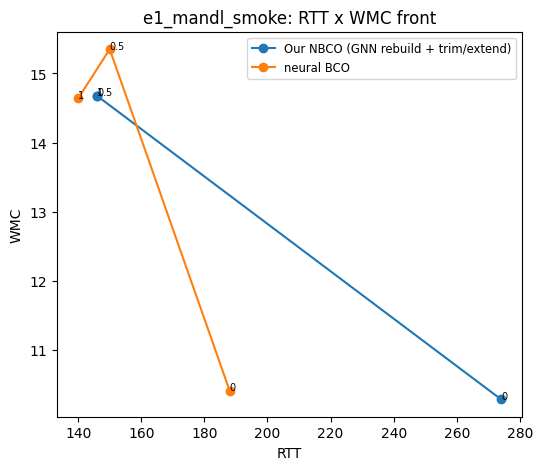

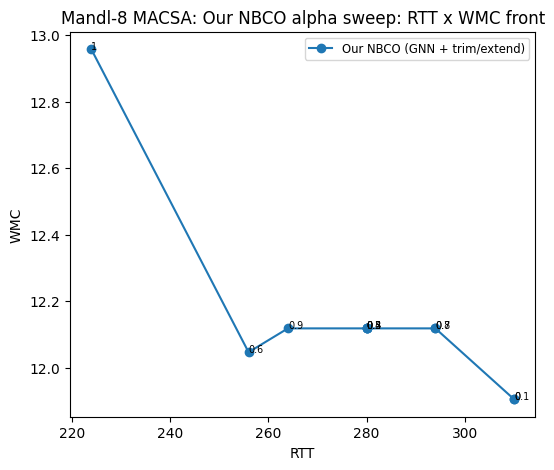

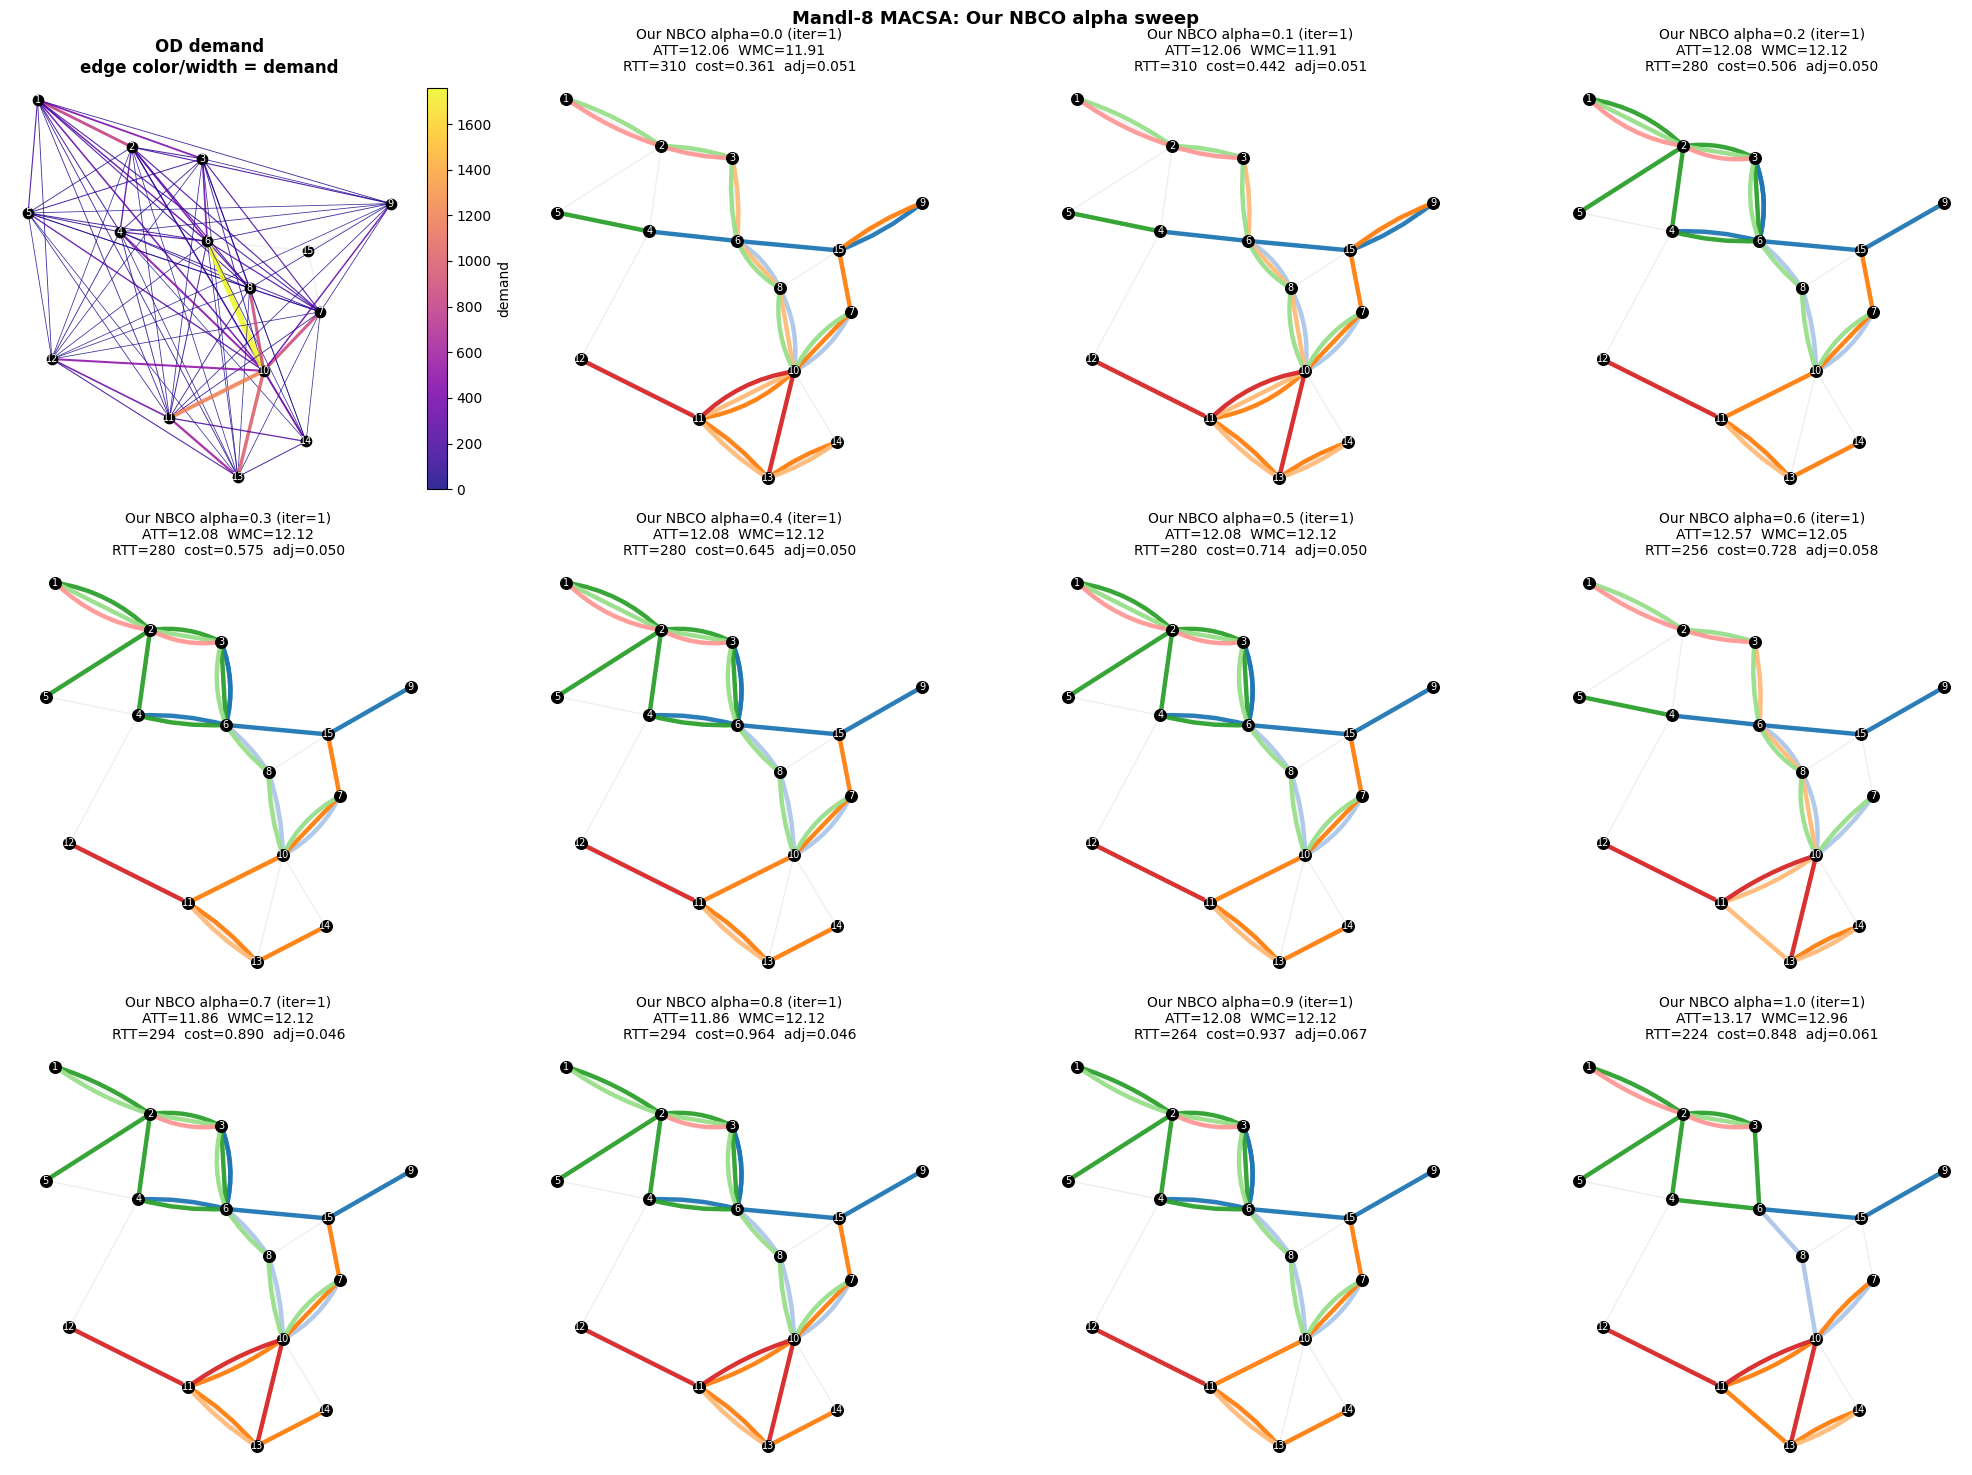

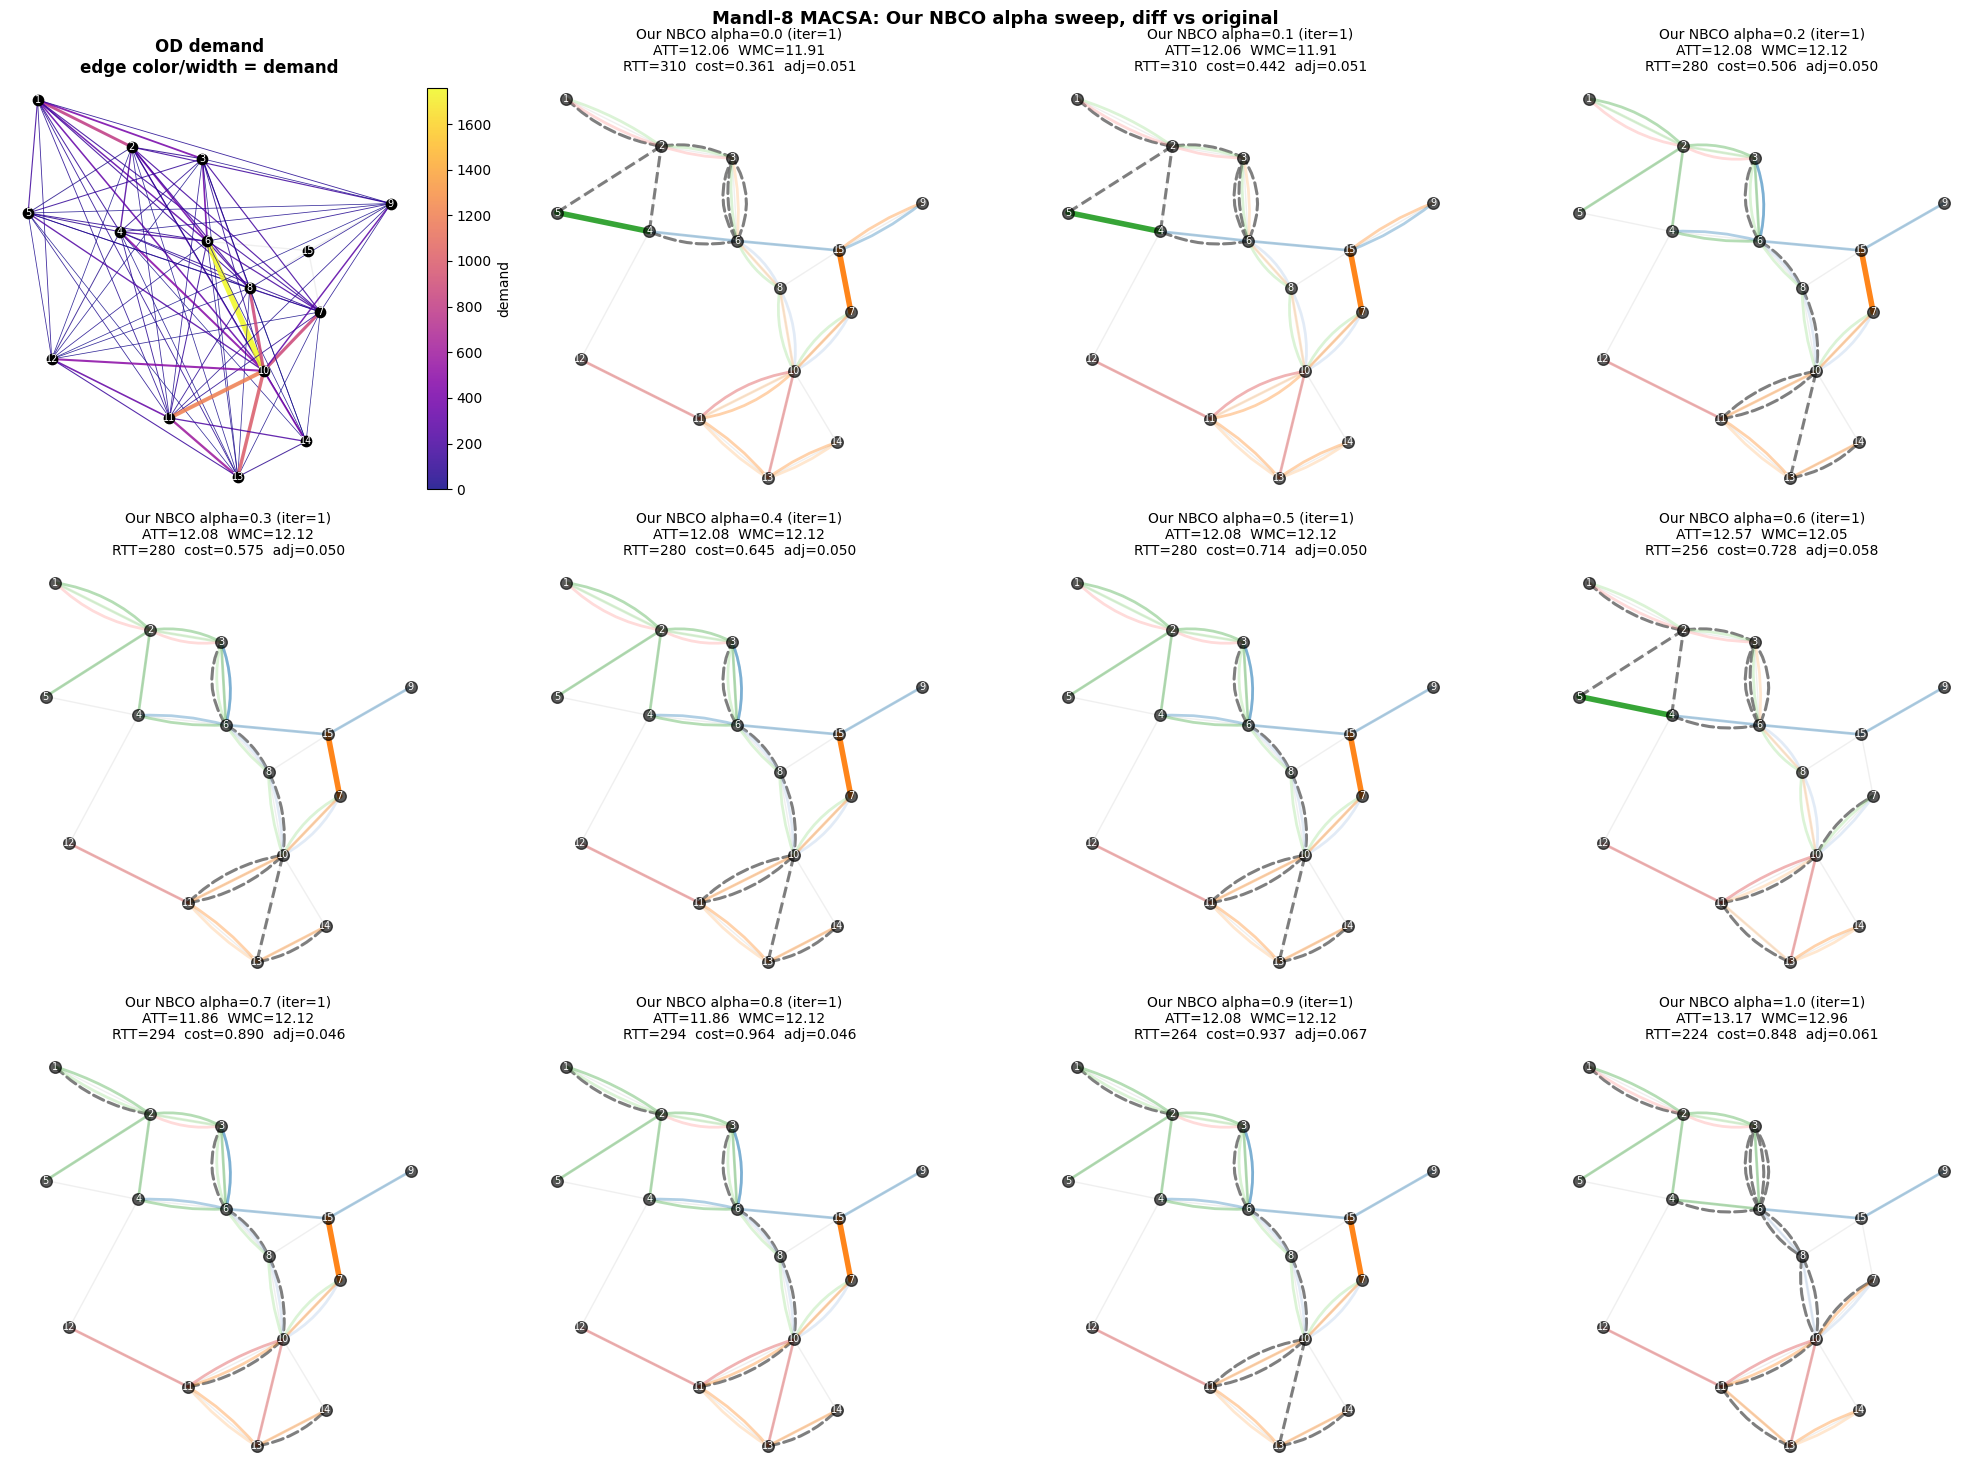

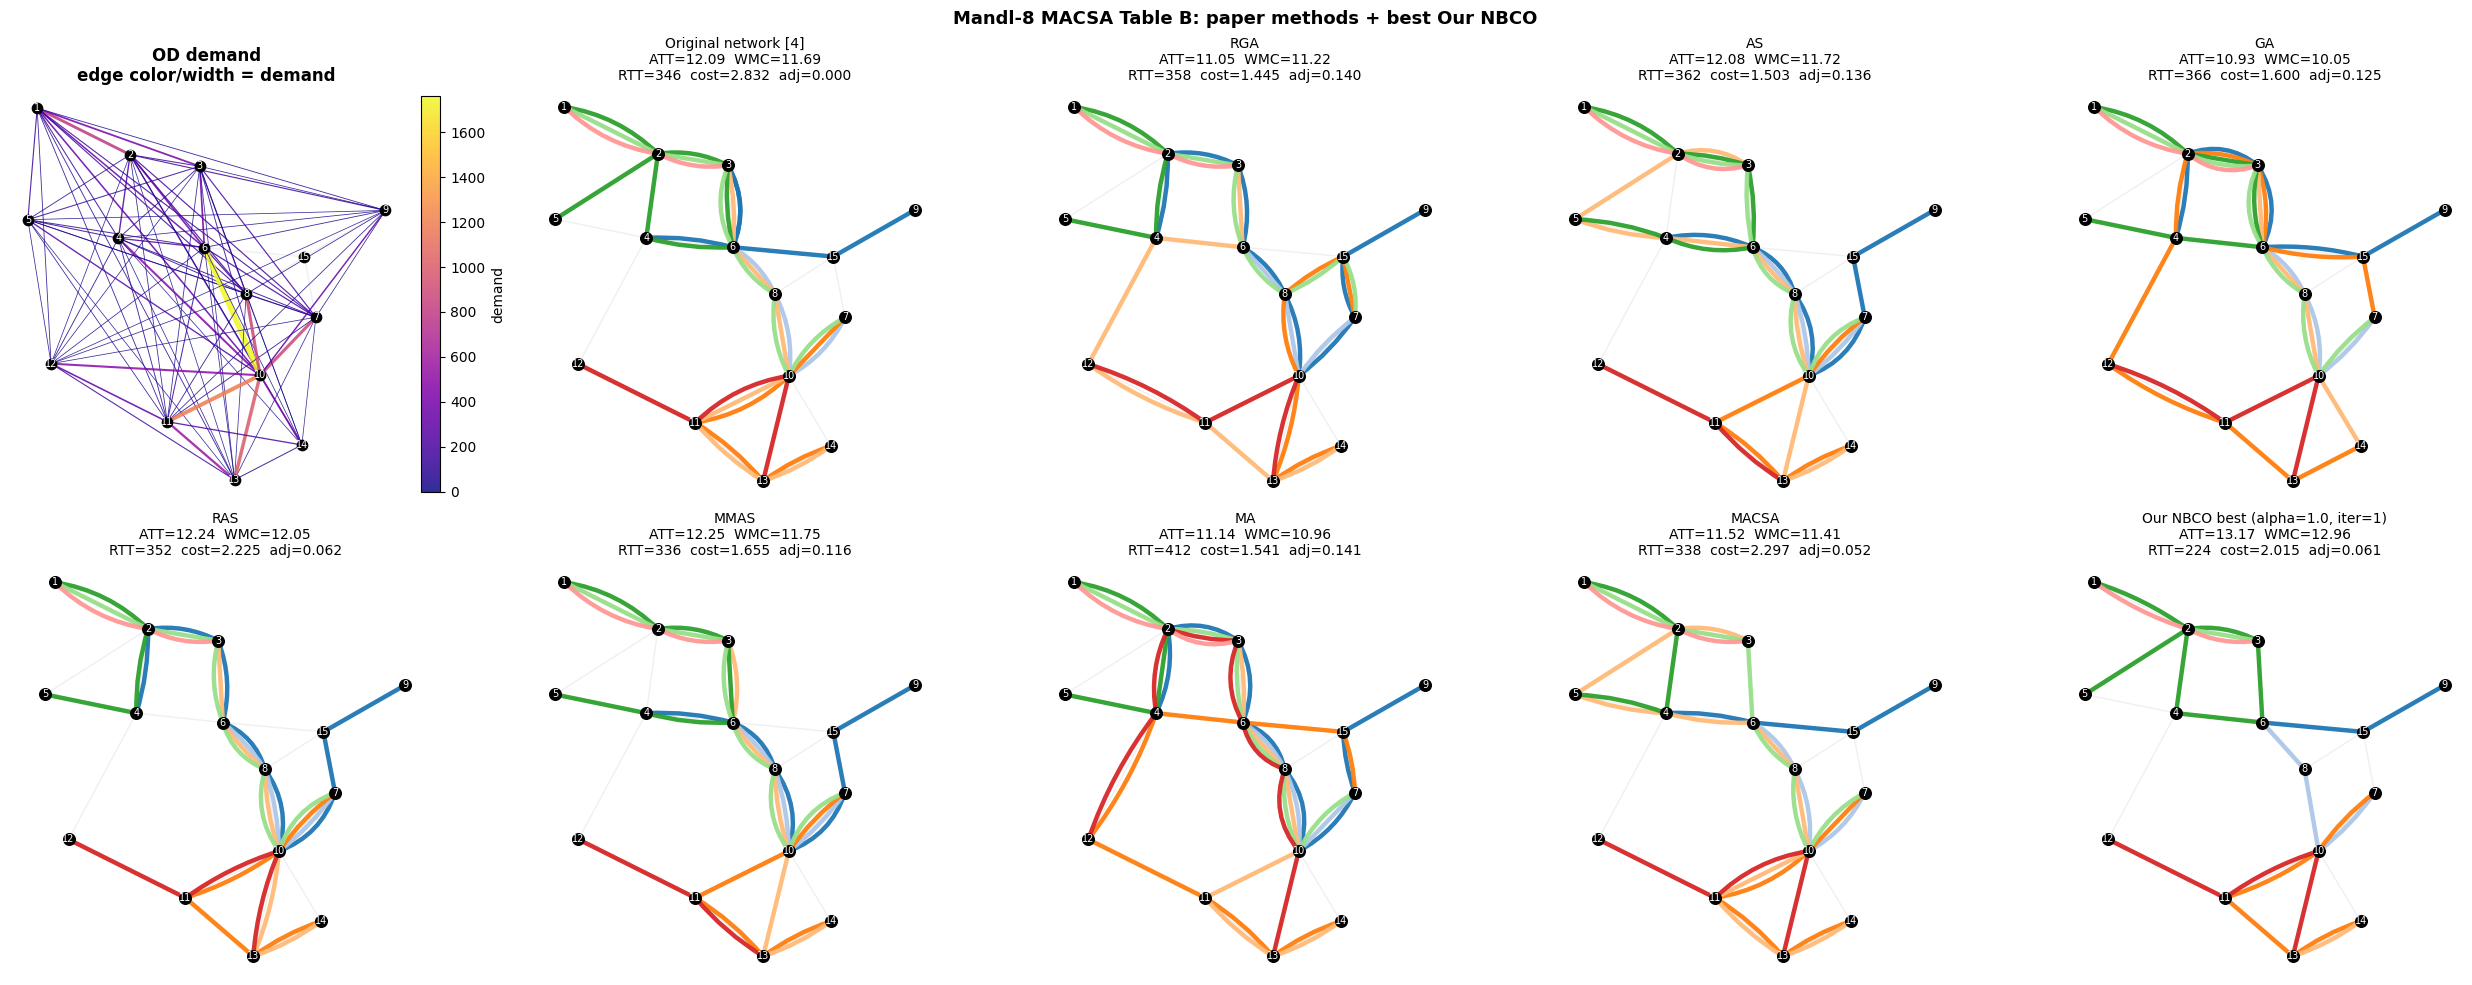

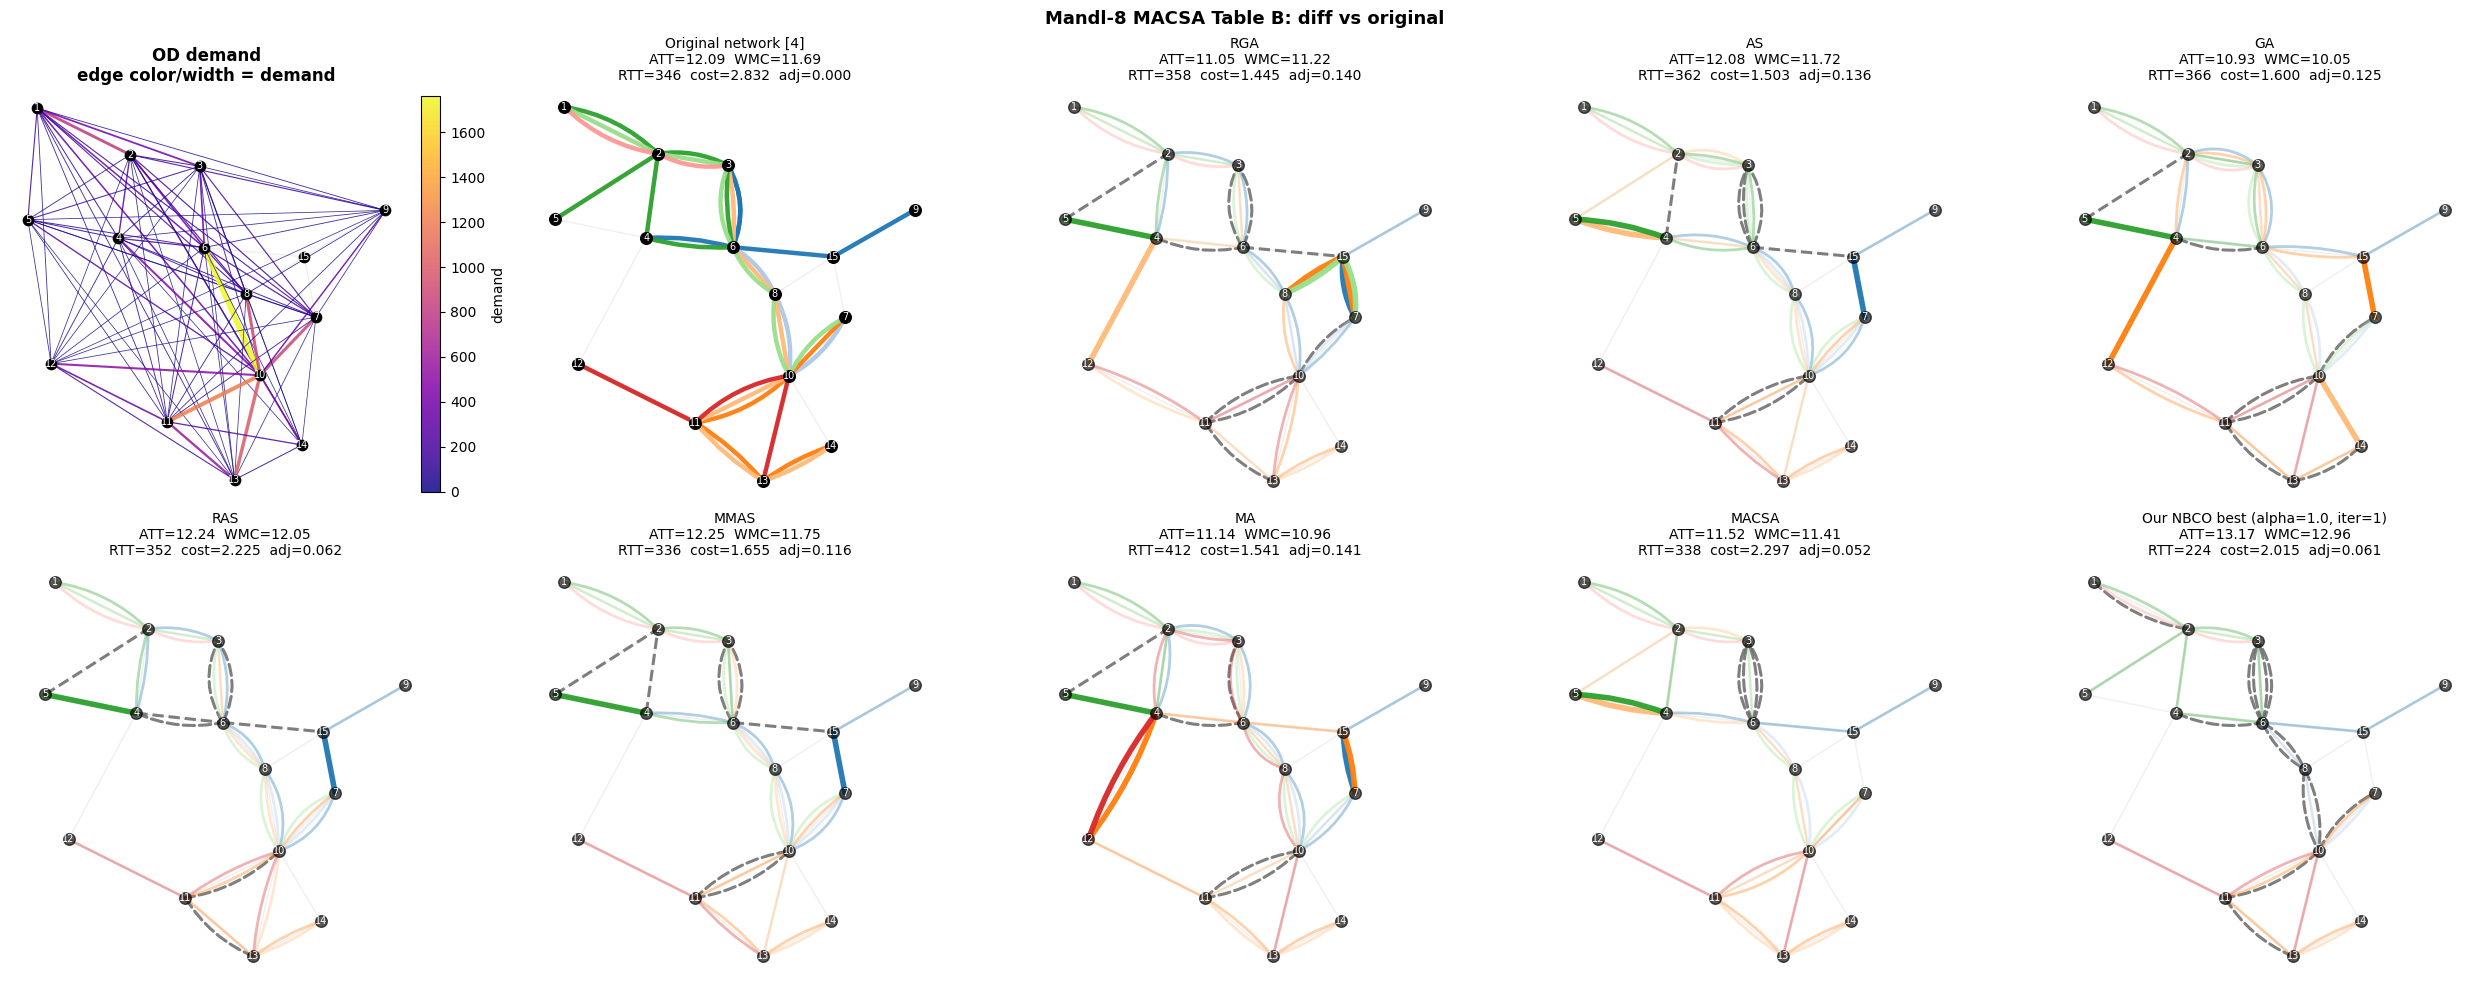

In [14]:
macsa.figures["comparison_plain"]
plt.show()

## 8. Обучение edit-политики (PPO) — режимы

Тренировочный конфиг — `cfg/train/<имя>.yaml` (`edit_scratch` — с нуля,
`edit_scratch_smoke` — 1-эпоховый smoke, `edit.yaml` — базовая группа).
`dry_run=True` собирает модель/cost/конфиг и валидирует связку без датасета и
PPO-цикла. Полное обучение (часы) запускается так же, но `.run()` без dry_run —
гоняет пользователь; warm-start задаётся `paths.init_checkpoint_path` в YAML.

In [15]:
from connectpt.routes_generator.paper_experiments.training_lc import load_train_config
from connectpt.routes_generator.training import EditTrainingRun

train_cfg = load_train_config("edit_scratch_smoke")
art8 = EditTrainingRun(train_cfg).run(dry_run=True)
art8.metadata

{'dry_run': True,
 'model_class': 'TrimPathCombiningRouteGenerator',
 'dataset_dir': 'D:\\PythonProjects\\connectpt\\datasets\\TEMP_smoke_lc_copytiers'}

## 9. Чекпоинты: загрузка старых весов

Старые веса (`artifacts/model_weights*`) — данные, они обязаны грузиться strict.
Модель строится фабрикой по имени конфига (`cfg/model_build/<имя>.yaml`), веса —
через `CheckpointStore`. Поисковые конфиги делают это сами (группа
`search/models/*` указывает config + checkpoint_path).

In [16]:
from connectpt.routes_generator.core.checkpoints import CheckpointStore
from connectpt.routes_generator.core.paths import EDIT_MODEL_WEIGHTS_DIR
from connectpt.routes_generator.model_factory import RouteModelFactory

model = RouteModelFactory.build_edit_model_by_name("edit_trim_seeded")
CheckpointStore.load_model_weights(
    model,
    EDIT_MODEL_WEIGHTS_DIR / "improvement_lc_rttconn_adj_w10_t02_finetune100.pt",
    strict=True)
type(model).__name__  # strict-загрузка прошла

'TrimPathCombiningRouteGenerator'

## 10. Тесты и полные бюджеты

- `pytest -q` — быстрый набор (~1 мин), включая approximate-parity против таргетов
  статьи на Mandl (`tests/test_paper_parity_mandl.py`);
- `pytest -m paper_full` — полные бюджеты Таблиц 1–2 (минуты–часы, opt-in);
- полные эксперименты статьи — `paper_combined.ipynb` с `load_suite("suite")`;
  таргеты лежат в `artifacts/paper_final/`, свежие выходы — в
  `artifacts/paper_results_v2/`.